# **Stage 3: AI Trends RAG Notebook**

*Team 5*

*Author: Irmak Ozarslan*




## **Q&A Dataset Construction**





First, we get the representative docs from BERTopic, to construct a Q&A Dataset that cover diverse AI topics
(e.g., generative AI, robotics, ethics, regulation). We will use LLM prompting to generate 200–300 Q&A pairs, then categorize these into factual, analytical, and comparative types. Finally, manually we will review and refine Q&A pairs for correctness and coverage.

### Install import packages


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import json
import ast

### Load data



In [2]:
ai_df = pd.read_csv("/content/drive/MyDrive/CLT/ai_media_clean_processed.csv")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CLT/ai_media_clean_processed.csv'

### Install requirements:



In [ ]:
!pip install -U langchain langchain-core langchain-community langchain-huggingface


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.9/469.9 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 20.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found e

In [ ]:
!pip install sentence-transformers
!pip install bertopic
!pip install umap-learn
!pip install hdbscan transformers accelerate einops
!pip install faiss-cpu langchain
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.1 MB/s eta 0:00:00


### Load the topic model:


In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

folder_path = "/content/drive/MyDrive/CLT"   # <-- directory, not .pkl
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

topic_model = BERTopic.load(str(folder_path), embedding_model=embedding_model)
print(topic_model.get_topic_info().head())


In [ ]:
representatives = topic_model.get_representative_docs()

unique_representative_docs = set(
    doc for docs in representatives.values() for doc in docs
)

print(f"Total unique representative documents: {len(unique_representative_docs)}")


In [ ]:
list(unique_representative_docs)[:10]


In [ ]:
# Saving the values of each column to a variable
print(df.head())
content = df["content"]
title = df["title"]
data = df["date"]
tags = df["tags"]
text_raw= df["text_raw"]
text_clean = df["text_clean"]
processed_text = df["processed_text"]
tokens = df["tokens"]




In [ ]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

folder_path_model = "/content/drive/MyDrive/CLT/bertopic_model1.pkl"
embedding_model=SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
loaded_model = BERTopic.load(folder_path_model, embedding_model=embedding_model)
topic_model = loaded_model

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [ ]:
topic_model.get_representative_docs()

{-1: ['["Comfort Systems USA\'s Q2 2025 earnings is scheduled for Thursday, July 24, 2025, with a conference call scheduled on Friday, July 25, 2025 at 11:00 AM ET. Check back for transcripts, audio, and key financial metrics as they become available.", "Good day, and thank you for standing by. Welcome to the Fourth Quarter twenty twenty four Comfort System USA Earnings Conference Call. At this time, all participants are in a listen only mode. After the speaker\'s presentation, there will be a question and answer session.", "To ask a question during this session, you will need to press 11 on your telephone. You will then hear automated message advising your hand is raised. To withdraw your question, please press 11 again. Please be advised that today\'s conference is being recorded. I would now like to hand the conference over to your first speaker today, Julie Shea, Chief Accounting Officer.", \'Please go ahead.\', "Thanks, Marvin. Good morning. Welcome to Comfort Systems USA\'s fourt

In [ ]:
topic_model.get_topic(1, full=True)

In [ ]:
topic_info = topic_model.get_topic_info()
print(topic_info.head())

topic_docs = {}
for topic_id in topic_info["Topic"].tolist():
    if topic_id == -1:
        continue
    top_docs = topic_model.get_representative_docs(topic_id)
    topic_docs[topic_id] = top_docs

rep_docs = []
for docs in topic_docs.values():
    rep_docs.extend(docs)

print(f"Total representative passages: {len(rep_docs)}")


In [ ]:
rep_docs

Let's clean the gpu before Q&A generation:

In [ ]:
del model
del llm_pipeline
del llm
del tokenizer
import gc
gc.collect()


In [ ]:
import torch
torch.cuda.empty_cache()


### Prepare docs for Q&A generation:

In [ ]:
import re
import ast

def clean_rep_doc_for_qa(doc):
    """
    Cleans a single rep_doc for Q&A generation:
    - Flattens lists and JSON-like strings
    - Removes very short/repeated lines
    - Returns a single string
    """

    flattened = []

    def flatten(item):
        if isinstance(item, list):
            for sub in item:
                yield from flatten(sub)
        elif isinstance(item, str):
            item_strip = item.strip()
            if item_strip.startswith("[") and item_strip.endswith("]"):
                try:
                    parsed = ast.literal_eval(item_strip)
                    yield from flatten(parsed)
                except:
                    yield item_strip
            else:
                yield item_strip
        else:
            yield str(item)

    for line in flatten(doc):
        line_clean = line.strip()
        if not line_clean:
            continue
        if len(line_clean) < 15:  # remove trivial lines
            continue
        flattened.append(line_clean)

    unique_lines = list(dict.fromkeys(flattened))

    cleaned_text = " ".join(unique_lines)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

def prepare_rep_docs_for_qa(rep_docs, max_words=1000):
    cleaned_passages = []
    for doc in rep_docs:
        cleaned = clean_rep_doc_for_qa(doc)
        if not cleaned:
            continue
        words = cleaned.split()
        if len(words) > max_words:
            cleaned = " ".join(words[:max_words])
        cleaned_passages.append(cleaned)
    return cleaned_passages



cleaned_passages = prepare_rep_docs_for_qa(rep_docs)



NameError: name 'rep_docs' is not defined

In [ ]:
print(f"Total passages ready for Q&A: {len(cleaned_passages)}")
print("Sample passage:", cleaned_passages[0][:500], "...")

In [ ]:
!pip install -U bitsandbytes

In [ ]:
import torch
import gc

del model
del tokenizer
del llm_pipeline  # or any large object
gc.collect()

torch.cuda.empty_cache()


### Generate questions:



Here we use google/flan-t5-large Model. We decided to use this after trying various models like Qwen Instruct, Mistral, falcon and checking their performance. Their performance was low (Qwen) in Q&A generation or they were (Mistral,falcon) computationally expensive. The most balanced model in that sense was the google/flan-t5-large model.

In [ ]:
import torch
import gc
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
from tqdm import tqdm
import pandas as pd

model_name = "google/flan-t5-large"
NUM_QA_PER_PASSAGE = 12
MAX_NEW_TOKENS = 200
TEMPERATURE = 0.2  # deterministic output
MAX_ENCODER_TOKENS = 150  # short chunks to avoid 512-token limit

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

qa_pipeline = pipeline(
    "text2text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto",
    max_new_tokens=MAX_NEW_TOKENS,
    do_sample=False,
    temperature=TEMPERATURE
)

def chunk_text(text, max_tokens=MAX_ENCODER_TOKENS):
    words = text.split()
    chunks, current = [], []
    for w in words:
        current.append(w)
        if len(tokenizer(" ".join(current)).input_ids) > max_tokens:
            chunks.append(" ".join(current[:-1]))
            current = [current[-1]]
    if current:
        chunks.append(" ".join(current))
    return chunks

def generate_qa(chunk):
    prompt = f"""
Generate ONE question from the passage below.
Output exactly in this format:
Q: [question]

Passage:
{chunk}
"""
    output = qa_pipeline(prompt)[0]["generated_text"]
    return output.strip()



KeyboardInterrupt: 

In [ ]:
output_file = "/content/ai_questions.txt"

with open(output_file, "w", encoding="utf-8") as f:
    for i, passage in enumerate(tqdm(cleaned_passages, desc="Generating Q&A")):
        print(f"\n=== Passage {i+1} Preview ===\n{passage[:300]}...\n")

        # Write passage as first line
        f.write(passage + "\n\n")

        passage_chunks = chunk_text(passage)
        qa_count = 0

        while qa_count < NUM_QA_PER_PASSAGE:
            for chunk in passage_chunks:
                qa_text = generate_qa(chunk)
                print(qa_text + "\n")

                # Extract questions from generated text
                for line in qa_text.splitlines():
                    line = line.strip()
                    if line.endswith("?") or line.startswith("Q:"):
                        # clean Q: prefix if present
                        question = line.replace("Q:", "").strip()
                        f.write(question + "\n")
                        qa_count += 1
                        if qa_count >= NUM_QA_PER_PASSAGE:
                            break
                if qa_count >= NUM_QA_PER_PASSAGE:
                    break

            # GPU cleanup
            torch.cuda.empty_cache()
            gc.collect()

        # Add a blank line between passages
        f.write("\n")

print(f"\nAll passages and questions saved to: {output_file}")


NameError: name 'cleaned_passages' is not defined

In [ ]:
with open("/content/drive/MyDrive/CLT/ai_questions.txt", "r", encoding="utf-8") as f:
    lines = [line.rstrip() for line in f if line.strip()]  # remove empty lines

qa_dict = {}
p_count = 0
current_passage = []
current_questions = []
global_q_counter = 1  # global question numbering

for line in lines:
    if line.endswith("?"):  # line is a question
        current_questions.append(line)
    else:
        # If we have collected a passage and its questions, save it
        if current_passage or current_questions:
            if current_passage:
                p_count += 1
                qa_dict[f"p{p_count}"] = {
                    "passage": " ".join(current_passage),
                    "questions": [
                        {"q_id": f"q{global_q_counter + i}", "q": q, "answer": "", "type": ""}
                        for i, q in enumerate(current_questions)
                    ]
                }
                global_q_counter += len(current_questions)
            current_passage = [line]
            current_questions = []
        else:
            current_passage.append(line)

if current_passage:
    p_count += 1
    qa_dict[f"p{p_count}"] = {
        "passage": " ".join(current_passage),
        "questions": [
            {"q_id": f"q{global_q_counter + i}", "q": q, "answer": "", "type": ""}
            for i, q in enumerate(current_questions)
        ]
    }

global_q_counter += len(current_questions)

with open("questions.txt", "w", encoding="utf-8") as f_q:
    for pid, pdata in qa_dict.items():
        f_q.write(f"{pid}:\n")
        for qdata in pdata["questions"]:
            f_q.write(f"{qdata['q_id']}: {qdata['q']}\n")
        f_q.write("\n")

with open("answers.txt", "w", encoding="utf-8") as f_a:
    for pid, pdata in qa_dict.items():
        f_a.write(f"{pid}:\n")
        for qdata in pdata["questions"]:
            f_a.write(f"{qdata['q_id']}: \n")
        f_a.write("\n")

print(f"Processed {p_count} passages with {global_q_counter - 1} questions.")



Processed 21 passages with 252 questions.


### Generate answers:

Now we will generate answers to our questions using the same model.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
from tqdm import tqdm
import os

with open("/content/drive/MyDrive/CLT/ai_questions.txt", "r", encoding="utf-8") as f:
    lines = [line.rstrip() for line in f if line.strip()]
qa_dict = {}
p_count = 0
current_passage = []
current_questions = []
global_q_counter = 1

for line in lines:
    if line.endswith("?"):  # line is a question
        current_questions.append(line)
    else:
        if current_passage or current_questions:
            if current_passage:
                p_count += 1
                qa_dict[f"p{p_count}"] = {
                    "passage": " ".join(current_passage),
                    "questions": [
                        {"q_id": f"q{global_q_counter + i}", "q": q, "answer": "", "type": ""}
                        for i, q in enumerate(current_questions)
                    ]
                }
                global_q_counter += len(current_questions)
            current_passage = [line]
            current_questions = []
        else:
            current_passage.append(line)

if current_passage:
    p_count += 1
    qa_dict[f"p{p_count}"] = {
        "passage": " ".join(current_passage),
        "questions": [
            {"q_id": f"q{global_q_counter + i}", "q": q, "answer": "", "type": ""}
            for i, q in enumerate(current_questions)
        ]
    }

global_q_counter += len(current_questions)

print(f" Processed {p_count} passages with {global_q_counter - 1} questions.")


model_name = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model.eval()  # evaluation mode

qa_pipeline = pipeline(
    "text2text-generation",
    model=model,
    tokenizer=tokenizer,
    device=-1,  # CPU
    max_new_tokens=150,
    do_sample=False,
    temperature=0.3
)

def chunk_text(text, max_tokens=150):
    words = text.split()
    chunks, current = [], []
    for w in words:
        current.append(w)
        if len(tokenizer(" ".join(current)).input_ids) > max_tokens:
            chunks.append(" ".join(current[:-1]))
            current = [current[-1]]
    if current:
        chunks.append(" ".join(current))
    return chunks


answers_path = "/content/drive/MyDrive/CLT/answers_live.txt"



print(f" Writing answers live to: {answers_path}")

for pid, pdata in tqdm(qa_dict.items(), desc="Passages", unit="passage"):
    passage = pdata["passage"]

    for qdata in tqdm(pdata["questions"], desc=f"{pid} questions", leave=False):
        question = qdata["q"]
        passage_chunks = chunk_text(passage)

        answers = []
        for chunk in passage_chunks:
            prompt = f"Passage: {chunk}\nQuestion: {question}\nAnswer shortly in one unique sentence."
            try:
                output = qa_pipeline(prompt)[0]["generated_text"].strip()
            except Exception as e:
                output = f"Error: {e}"
            answers.append(output)

        full_answer = " ".join(answers)

        print(f"{qdata['q_id']} | Q: {question}\nA: {full_answer}\n{'-'*60}")

        with open(answers_path, "a", encoding="utf-8") as f_out:
            f_out.write(f"{qdata['q_id']} | Q: {question}\nA: {full_answer}\n{'-'*60}\n")
            f_out.flush()  # force write to disk immediately

print(f"\n All answers saved continuously to: {answers_path}")


 Processed 21 passages with 252 questions.


Device set to use cpu


 Writing answers live to: /content/drive/MyDrive/CLT/answers_live.txt


p1 questions:   8%|▊         | 1/12 [03:01<33:18, 181.69s/it]

q1 | Q: What is not a type of myth about artificial intelligence?
A: AI wasn’ t particularly noteworthy at the time; it was merely one of hundreds of emerging technologies being presented to the tech industry; nothing too special. humans, who think creatively and emotionally, AI lacks the presence of consciousness and self-awareness The apparent intelligence of AI is often mistaken for real comprehension. It doesn’ t understand the meaning of its outputs; when AI does language translation, it performs a task based on pattern recognition, statistics, and data identification from it’ s dataset of different languages. It does not understanding the subtleties of the language in its cultural or contextual usage. a tool designed to enhance human abilities, not replace them. So don’ t get scared of the machine rebellion just yet. General AI models that have even a small chance of taking over the world construct an ethical set of guidelines with considerable technical and regular careful tests

...

q125 | Q: What is one obstacle to quantum computing?
A: encryption and stealth the more immediate policy questions are how to accelerate research, how to develop new quantum technologies, and how to use ( or in some cases, protect against) these technologies’ different applications the software needed for quantum computing is very different from conventional computing software qubits can simultaneously represent 1, 0, or any value in between Quantum chips are expensive One obstacle to quantum computing is the need to improve qubits so they are less prone to making calculation errors due to “ noise, ” which can be anything from radio signals to disturbances in the Earth’ s magnetic field. Quantum chips themselves need to be simplified to allow each chip to contain multiple qubits without the complex wiring now required, since error correction requires the ability to use multiple qubits simultaneously. it is not currently feasible to install a quantum computer on every desk Cryptography 


p11 questions:  50%|█████     | 6/12 [19:54<20:07, 201.18s/it]

q126 | Q: How can error correction software be used to fix qubit errors?
A: Quantum physics is the “ study of matter and energy at the most fundamental level. ” Quantum technologies exploit the properties identified by quantum physics to provide new capabilities in computing, communications, and sensing. While quantum phenomena have been studied for decades, important technologies based on those phenomena have only appeared relatively recently. The infrastructure for research and services includes quantum computers and the specialized chips they use, new kinds of sensors, quantum communication devices, and unique software, Quantum computing uses quantum physics to solve problems at speeds not possible with classical computers Quantum computing’ s security applications include being able to “ break ” secure encryption, perform complex simulations, and allow the analysis Quantum chips are expensive ( one estimate is $ 10,000 a qubit, compared to under $ 200 for a conventional chip) and t


p11 questions:  58%|█████▊    | 7/12 [23:22<16:56, 203.34s/it]

q127 | Q: What is the need for specialized support equipment and the fragility of qubits?
A: Quantum technologies exploit the properties identified by quantum physics to provide new capabilities in computing, communications, and sensing. While quantum phenomena have been studied for decades, important technologies based on those phenomena have only appeared relatively recently. The infrastructure for research and services includes quantum computers and the specialized chips they use, new kinds of sensors, quantum communication devices, and unique software, Quantum computing uses quantum physics to solve problems at speeds not possible with classical computers Quantum computing’ s security applications include being able to “ break ” secure encryption, perform complex simulations, and allow the analysis Quantum chips are expensive ( one estimate is $ 10,000 a qubit, compared to under $ 200 for a conventional chip) and they require a host of specialized support equipment One obstacle to 

In [ ]:
answers_file = "/content/drive/MyDrive/CLT/answers_live.txt"  # 🔹 upload your file to Colab first
with open(answers_file, "r", encoding="utf-8") as f:
    data = f.read()

In [ ]:
import re
import pandas as pd
from transformers import pipeline

answers = {}
qa_blocks = re.split(r"-{5,}", data)
for block in qa_blocks:
    match = re.search(r"q(\d+)\s*\|\s*Q:\s*(.*?)\s*A:\s*(.*)", block, re.S)
    if match:
        q_id = f"q{match.group(1).strip()}"
        question = match.group(2).strip().replace("\n", " ")
        answer = match.group(3).strip().replace("\n", " ")
        answers[q_id] = {"question": question, "answer": answer}

print(f"Parsed {len(answers)} Q&A pairs")

records = []
for passage_id, data in qa_dict.items():
    passage = data["passage"]
    for q in data["questions"]:
        q_id = q["q_id"]
        question = q["q"]
        answer = answers.get(q_id, {}).get("answer", "")
        records.append({
            "passage_id": passage_id,
            "question_id": q_id,
            "passage": passage,
            "question": question,
            "answer": answer
        })

qa_data = pd.DataFrame(records)
print(f"Created DataFrame with {(qa_data).head()} rows")

Parsed 147 Q&A pairs
Created DataFrame with   passage_id question_id                                            passage  \
0         p1          q1  The majority of you reading this article today...   
1         p1          q2  The majority of you reading this article today...   
2         p1          q3  The majority of you reading this article today...   
3         p1          q4  The majority of you reading this article today...   
4         p1          q5  The majority of you reading this article today...   

                                            question  \
0  What is not a type of myth about artificial in...   
1  What are the most believable and shocking AI m...   
2  What is the apparent intelligence of AI often ...   
3               What are the two types of AI models?   
4  What is the difference between Narrow AI model...   

                                              answer  
0  AI wasn’ t particularly noteworthy at the time...  
1  The majority of you reading thi

In [ ]:
qa_data.head()

,passage_id,question_id,passage,question,answer
0,p1,q1,The majority of you reading this article today...,What is not a type of myth about artificial in...,AI wasn’ t particularly noteworthy at the time...
1,p1,q2,The majority of you reading this article today...,What are the most believable and shocking AI m...,The majority of you reading this article today...
2,p1,q3,The majority of you reading this article today...,What is the apparent intelligence of AI often ...,Artificial intelligence is changing our everyd...
3,p1,q4,The majority of you reading this article today...,What are the two types of AI models?,artificial intelligence is changing our everyd...
4,p1,q5,The majority of you reading this article today...,What is the difference between Narrow AI model...,The majority of you reading this article today...


  We observe that answers and questions sometimes repeated but not at great extent. Some questions are generated in multiple choice format which is not in line with our task. Also even though in the prompt it was said to have 1 line answer, the answers contain multiple lines as in paragraphs. After careful observation, the first sentence seems more accurate and the rest seems like an artifact. I might do a cleaning regarding this and leave only the first sentence as answer. However, we have variety of topics, from AI myths to healthcare and business ventures to politics. The coverage seems good. After visual inspection, correctness also seems good around %80.

In [ ]:
from transformers import pipeline
from tqdm.auto import tqdm
import torch

MODEL_NAME = "facebook/bart-large-mnli"
device = 0 if torch.cuda.is_available() else -1
classifier = pipeline("zero-shot-classification", model=MODEL_NAME, device=device)

labels = ["Conceptual", "Comparative", "Analytical"]

pred_types, confidences = [], []

for _, row in tqdm(qa_data.iterrows(), total=len(qa_data), desc="Classifying"):
    text = f"Question: {row['question']}\nAnswer: {row['answer']}"
    result = classifier(text, candidate_labels=labels)
    pred_types.append(result["labels"][0])
    confidences.append(round(result["scores"][0], 3))

qa_data["predicted_type"] = pred_types
qa_data["confidence"] = confidences

qa_data = qa_data[["passage_id", "passage", "question_id", "question", "answer", "predicted_type", "confidence"]]

display(qa_data.head(10))


Device set to use cpu


Classifying:   0%|          | 0/252 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
qa_data.to_csv("//content/drive/MyDrive/CLT/qa_results.csv", index=False)


In [3]:
qa_data= pd.read_csv("C:\\Users\\irmak\\Downloads\\FILES\\qa_results.csv")

In [ ]:
qa_data["confidence"].mean()

np.float64(0.5578730158730159)

The model was not so confident in categorizing the questions as we see in average 0.55 confidence rate. We observe that the questions asking the main idea are also categorized as comparative however, it should be conceptual.

In [ ]:
qa_data['predicted_type'].value_counts()

,count
predicted_type,
Comparative,202
Conceptual,46
Analytical,4


As we see there is an imbalance in the questions. There are more comparative classification than conceptual and analytical is really a few. However, this can be due to the AI trends content, as there were not so much analytical information.

    passage_id                                            passage question_id  \
71          p6  No one can dispute that AI in healthcare has c...         q72   
164        p14  Email address: By clicking submit, you agree t...        q165   
240        p21  This issue is preventing our website from load...        q241   
92          p8  We’ re so glad you’ re here. You can expect al...         q93   
146        p13  Email address: By clicking submit, you agree t...        q147   

                                              question  \
71   How will AI algorithms enhance data accuracy a...   
164  What are the types of possibilities, not just ...   
240  What types of articles does Foreign Policy Mag...   
92      What kind of analysis is the passage based on?   
146  Which city has experienced rapid growth in its...   

                                                answer predicted_type  \
71   Practical application in clinical settings cou...    Comparative   
164               

<Axes: title={'center': 'Distribution of Q&A Types'}, xlabel='predicted_type'>

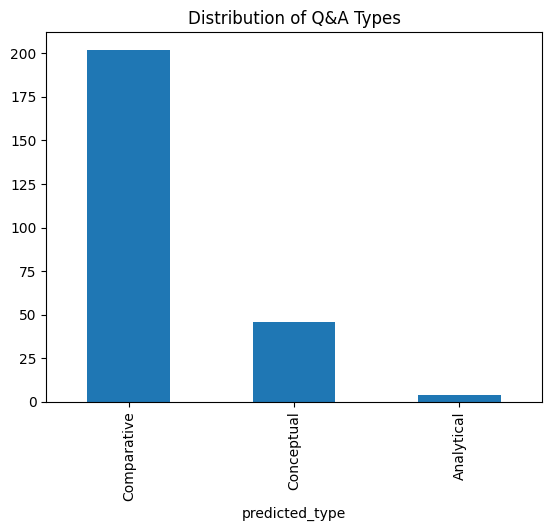

In [ ]:
print(qa_data.sample(5))

qa_data['predicted_type'].value_counts().plot(kind='bar', title='Distribution of Q&A Types')



## Knowledge Graph Extraction

Explores how combining structured knowledge (graph) with unstructured text retrieval improves Q&A performance.

In [13]:
import requests
import json
drive_path = '/content/drive/MyDrive/AI_Knowledge_Graph/'

import os
os.makedirs(drive_path, exist_ok=True)

url = "http://85.214.245.200:7004/graph"
try:
    resp = requests.get(url)
    resp.raise_for_status()
    graph_data = resp.json()
    print(f"Fetched {len(graph_data.get('nodes', []))} nodes and {len(graph_data.get('connections', []))} connections.")
except Exception as e:
    print(f"Error fetching data: {e}")
    graph_data = None

if graph_data:
    raw_file = os.path.join(drive_path, 'ai_graph_raw.json')
    with open(raw_file, 'w', encoding='utf-8') as f:
        json.dump(graph_data, f, ensure_ascii=False, indent=2)
    print(f"Saved raw graph data to {raw_file}")

    nodes = graph_data.get("nodes", [])
    connections = graph_data.get("connections", [])

    filtered_nodes = [n for n in nodes if n.get("type") == "UseCase"]
    filtered_connections = [c for c in connections if c.get("strength", 0) > 0.5]

    processed = {
        "nodes": filtered_nodes,
        "connections": filtered_connections
    }

    processed_file = os.path.join(drive_path, 'ai_graph_processed.json')
    with open(processed_file, 'w', encoding='utf-8') as f:
        json.dump(processed, f, ensure_ascii=False, indent=2)
    print(f"Saved processed graph data to {processed_file}")

Fetched 1932 nodes and 14940 connections.
Saved raw graph data to /content/drive/MyDrive/AI_Knowledge_Graph/ai_graph_raw.json
Saved processed graph data to /content/drive/MyDrive/AI_Knowledge_Graph/ai_graph_processed.json


In [12]:
with open("C:\\Users\\irmak\\Downloads\\FILES\\graph_clt.json", 'r', encoding='utf-8') as f:
    graph_data = json.load(f)

nodes = graph_data.get("nodes", [])
connections = graph_data.get("connections", [])

print(f"Loaded {len(nodes)} nodes and {len(connections)} connections.")

Loaded 64801 nodes and 0 connections.


In [ ]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.2 MB/s eta 0:00:00


In [9]:
graph_data

{'nodes': [{'activity': 'High',
   'connections': 12,
   'description': 'Description not available yet.',
   'long_description': 'Long description not available yet.',
   'name': 'Automated Content Generation',
   'nodeId': 'AutomatedContentGeneration',
   'popularity': 0.25,
   'properties': [],
   'trend': -86.11,
   'type': 'UseCase'},
  {'activity': 'High',
   'connections': 5,
   'description': 'Description not available yet.',
   'long_description': 'Long description not available yet.',
   'name': 'Audience Segmentation & Targeting',
   'nodeId': 'AudienceSegmentation&Targeting',
   'popularity': 0.12,
   'properties': [],
   'trend': -79.8,
   'type': 'UseCase'},
  {'activity': 'High',
   'connections': 3,
   'description': 'Description not available yet.',
   'long_description': 'Long description not available yet.',
   'name': 'SEOOptimization',
   'nodeId': 'SEOOptimization',
   'popularity': 0.33,
   'properties': [],
   'trend': -77.41,
   'type': 'UseCase'},
  {'activity'

In [14]:
import networkx as nx
import json
import os



nodes = graph_data.get("nodes", [])
connections = graph_data.get("connections", [])

# Create networkx graph
G_api = nx.Graph()

type_colors = {
    "UseCase": "#1f77b4",
    "Tool": "#ff7f0e",
    "Dataset": "#2ca02c",
    "Concept": "#d62728",
    # add more types if needed
}

# Add nodes
for n in nodes:
    node_id = n.get('nodeId', n.get('name'))
    node_label = n.get('name', node_id)
    node_type = n.get('type', 'Other')
    popularity = n.get('popularity', 0.1)  # scale size
    G_api.add_node(node_id, label=node_label, color=type_colors.get(node_type, "#7f7f7f"), size=5 + popularity*20)

# Add edges
for c in connections:
    source = c.get('source')
    target = c.get('target')
    strength = c.get('strength', 0.5)
    if source and target:
        G_api.add_edge(source, target, value=strength)



In [ ]:
from IPython.core.display import display, HTML

# Path to the HTML file
output_html = '/content/AI_Knowledge_Graph.html'

# Embed the interactive graph directly in Colab
display(HTML(filename=output_html))


The load was successful. We see the main nodes in this graph, such as personalization, drug discovery, document managment etc.

In [ ]:


print(f"Graph ready: {len(nodes)} nodes, {len(connections)} connections.")


Graph ready: 106 nodes, 8325 connections.


In [6]:
json_path = "/content/drive/MyDrive/CLT/ai_semantic_graph.json"

with open(json_path, "r") as f:
    graph_data_project = json.load(f)

In [6]:
aim = pd.read_pickle("/content/drive/MyDrive/CLT/aim_with_ner_c.pkl")
print(type(aim), aim.shape, aim.columns[:10])
aim.head()

<class 'pandas.core.frame.DataFrame'> (16527, 34) Index(['title', 'date', 'content', 'domain', 'url', 'tags', 'text_raw',
       'text_clean', 'tokens', 'processed_text'],
      dtype='object')


,title,date,content,domain,url,tags,text_raw,text_clean,tokens,processed_text,...,ent_PERCENT,ent_PERSON,ent_PRODUCT,ent_QUANTITY,ent_TIME,ent_WORK_OF_ART,entities_flat,entities_dict,spo_triples,text_raw_c
0,Ricoh to provide customer support for Agility ...,2024-09-11,['The Digit humanoid could work in distributio...,therobotreport,https://www.therobotreport.com/ricoh-provides-...,"['Robotics', 'Video', 'BostonDynamics']","The Digit humanoid could work in distribution,...","the digit humanoid could work in distribution,...","['the', 'digit', 'humanoid', 'could', 'work', ...",the digit humanoid could work in distribution ...,...,None,None,None,None,None,None,"[this fall, Apollo, Kirby, Atlas, later this y...","{'CARDINAL': ['one', '1X', '6', '02', '35 to 5...","[(Source, announce, partnership), (it, expand,...","The Digit humanoid could work in distribution,..."
1,MTV VMAs 2024: Live shopping is coming to the ...,2024-09-11,"['In this article', ""When viewers tune in to t...",cnbc,https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...,['GenerativeAI'],In this article When viewers tune in to the 20...,in this article when viewers tune in to the 20...,"['in', 'this', 'article', 'when', 'viewers', '...",in this article when viewers tune in to the mt...,...,None,None,None,None,None,None,"[earlier this year, its second quarter, Wednes...","{'CARDINAL': ['1', '2', 'over 1,000'], 'DATE':...","[(Shopsense, tell, CNBC), (viewers, snap, phot...",In this article When viewers tune in to the 20...
2,Open-source imagery is transforming investigat...,2024-09-11,['Open-source online imagery can play a vital ...,theconversation,https://www.theconversation.com/open-source-im...,"['Disinformation', 'Video', 'Deepfake', 'Infor...",Open-source online imagery can play a vital ro...,open-source online imagery can play a vital ro...,"['open', 'source', 'online', 'imagery', 'can',...",open source online imagery can play a vital ro...,...,None,None,None,None,None,None,"[Volodymyr Zelensky, a particular day, AI, s m...","{'CARDINAL': ['One', 'two'], 'DATE': ['a parti...","[(imagery, play, role), (courts, assess, authe...",Open-source online imagery can play a vital ro...
3,"With China seeking AI dominance, Taiwan’ s eff...",2024-09-11,"['Tensions between China, Taiwan and the U.S. ...",theconversation,https://www.theconversation.com/with-china-see...,"['MilitaryAndDefense', 'Missiles', 'HighPerfor...","Tensions between China, Taiwan and the U.S. ar...","tensions between china, taiwan and the u.s. ar...","['tensions', 'between', 'china', 'taiwan', 'an...",tensions between china taiwan and the aren t l...,...,None,None,None,None,None,None,"[the first quarter of 2024, China, National Bu...","{'CARDINAL': ['14', 'one', 'Four', 'One', '10-...","[(it, import, oil), (reliance, add, layer), (c...","Tensions between China, Taiwan and the US. are..."
4,Study links EV charging stations to increased ...,2024-09-11,['Countries globally are rapidly transitioning...,phys,https://phys.org/news/2024-09-links-ev-station...,"['Causality', 'Planning']",Countries globally are rapidly transitioning t...,countries globally are rapidly transitioning t...,"['countries', 'globally', 'are', 'rapidly', 't...",countries globally are rapidly transitioning t...,...,None,None,None,None,None,None,"[the first quarter of 2024, Interdisciplinary ...","{'CARDINAL': ['one', '140,000', 'more than one...","[(Researchers, publish, study), (that, demonst...",Countries globally are rapidly transitioning t...


In [11]:
!pip install nltk

There are some stop words like we I you etc. we have to clean before constructing the graph.

In [7]:
import nltk
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
import networkx as nx
from tqdm import tqdm
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

G_ai = nx.DiGraph()

print("Building graph from dataframe...")

for idx, row in tqdm(aim.iterrows(), total=len(aim)):
    doc_id = idx  # use index as unique node id

    # Add the document itself as a node
    G_ai.add_node(
        doc_id,
        type="DOCUMENT",
        title=row.get('title', ''),
        url=row.get('url', ''),
        content=row.get('content', ''),
        processed_text=row.get('processed_text', ''),
        entities=row.get('entities_dict', {}),
        triples=row.get('spo_triples', [])
    )

    # Add edges for each triple
    triples = row.get('spo_triples') or []
    entities = row.get('entities_dict', {})

    for subj, verb, obj in triples:
        # Skip trivial nodes
        if subj.lower() in stop_words or obj.lower() in stop_words:
            continue
        if len(subj) < 2 or len(obj) < 2:
            continue

        # Determine types from entities dict
        subj_type = next((k for k, v in entities.items() if subj in v), "UNKNOWN")
        obj_type  = next((k for k, v in entities.items() if obj in v), "UNKNOWN")

        # Add nodes for subject/object if not already
        if subj not in G_ai:
            G_ai.add_node(subj, type=subj_type)
        if obj not in G_ai:
            G_ai.add_node(obj, type=obj_type)

        # Add edge from subject to object, optionally connect document too
        G_ai.add_edge(subj, obj, relation=verb)
        # Optional: connect document node to entities
        G_ai.add_edge(doc_id, subj, relation="MENTIONS")
        G_ai.add_edge(doc_id, obj, relation="MENTIONS")


Building graph from dataframe...


100%|██████████| 16527/16527 [00:10<00:00, 1611.06it/s]


Edges:

From document → entity with relation "MENTIONS" (so the document “mentions” that entity).

Between entity → entity with relation from spo_triples (subj → obj with verb).

In [68]:
import networkx as nx
import json

def save_graph_json_stream(graph, filename):
    with open(filename, "w", encoding="utf-8") as f:
        f.write("{\n")
        # Nodes
        f.write('"nodes": [\n')
        first = True
        for n, attrs in graph.nodes(data=True):
            if not first:
                f.write(",\n")
            json.dump({"id": n, **attrs}, f, ensure_ascii=False)
            first = False
        f.write("\n],\n")

        # Edges
        f.write('"edges": [\n')
        first = True
        for u, v, attrs in graph.edges(data=True):
            if not first:
                f.write(",\n")
            json.dump({"source": u, "target": v, **attrs}, f, ensure_ascii=False)
            first = False
        f.write("\n]\n")
        f.write("}\n")

# Usage
save_graph_json_stream(G, "graph_clt.json")


## RAG Implementation

Got inspired from https://github.com/LuciferUchiha/Cleantech-RAG) to set up the system.

We chunked the document with recursive chunking and semantic chunking. At the end I used recursive chunking since semantic chunking took really long. Followingly, embedded the chunks using mini llm from HuggingFace then stored it in ChromeDB. After, we experimented with different retrieval strategies, e.g., hybrid search (dense + sparse), graph-aware retrieval using graph from the API provided and the generated graph using llm google flon. Checked if answers reference retrieved passages and graph entities/relations where possible.

In [9]:
%%writefile requirements.txt

chromadb
datasets
langchain
langchain-community
langchain-experimental
langchain-openai
langdetect
lorem-text
nbformat>=4.2.0
openai==1.57.1
plotly
pretty-jupyter
ragas
seaborn
sentence-transformers
spacy>=3.7
textstat
umap-learn
langchain-chroma


Overwriting requirements.txt


In [10]:
!pip install -r requirements.txt

In [ ]:
!pip install --upgrade chromadb


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: posthog
    Found existing installation: posthog 6.8.0
    Uninstalling posthog-6.8.0:
      Successfully uninstalled posthog-6.8.0
  Attempting uninstall: chromadb
    Found existing installation: chromadb 0.5.0
    Uninstalling chromadb-0.5.0:
      Successfully uninstalled chromadb-0.5.0


In [16]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
import torch
import os
import pickle
import pandas as pd
from tqdm import tqdm
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from datasets import Dataset
from dotenv import load_dotenv
from langdetect import detect
from lorem_text import lorem
from ragas import RunConfig, evaluate
from ragas.metrics import (faithfulness, answer_relevancy, answer_correctness)
from spacy.lang.en import English
from textstat import flesch_reading_ease
from tqdm import tqdm
import umap

from langchain.chains.base import Chain
from langchain.text_splitter import RecursiveCharacterTextSplitter, TextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma, VectorStore
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.embeddings import Embeddings
from langchain_core.language_models import LLM
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.retrievers import BaseRetriever
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai import ChatOpenAI, OpenAIEmbeddings


In [11]:
ai_df["text"] = ai_df.apply(lambda r: f"Title: {r['title']}\nDate: {r['date']}\nDomain: {r['domain']}\n\n{r['processed_text']}", axis=1)
ai_df = ai_df.dropna(subset=["text"])
print("Dataset size:", len(ai_df))
ai_df.head(2)

Dataset size: 16527


,title,date,content,domain,url,tags,text_raw,text_clean,tokens,processed_text,text
0,Ricoh to provide customer support for Agility ...,2024-09-11,['The Digit humanoid could work in distributio...,therobotreport,https://www.therobotreport.com/ricoh-provides-...,"['Robotics', 'Video', 'BostonDynamics']","The Digit humanoid could work in distribution,...","the digit humanoid could work in distribution,...","['digit', 'humanoid', 'work', 'distribution', ...",digit humanoid work distribution retail commer...,Title: Ricoh to provide customer support for A...
1,MTV VMAs 2024: Live shopping is coming to the ...,2024-09-11,"['In this article', ""When viewers tune in to t...",cnbc,https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...,['GenerativeAI'],In this article When viewers tune in to the 20...,in this article when viewers tune in to the 20...,"['article', 'viewer', 'tune', 'mtv', 'vma', 'w...",article viewer tune mtv vma wednesday night ab...,Title: MTV VMAs 2024: Live shopping is coming ...


### Chunking

The right chunking strategy is important. Chunk size drastically influences performance, smaller chunks are better for similarity search however to compute embeddings and store in vectordb it is computationally expensive. Since we have a dataset with ~16000 docs and these docs are long paragraphs, we need to find an optimal size for chunks. We can try 1200 for recursive chunking.

In [10]:
import os
import pickle
import pandas as pd
from tqdm import tqdm
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
import torch


device = "cuda"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"

model_kwargs = {"device": device, "trust_remote_code": True}

# Splitters (recursive and semantic)

def get_recursive_splitter():
    return RecursiveCharacterTextSplitter(
        chunk_size=1200,
        chunk_overlap=100,
        separators=["\n\n", "\n", "(?<=\. )", " ", ""],
        length_function=len
    )

def get_semantic_splitter():
    embed_model = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        model_kwargs={"device": "cuda", "trust_remote_code": True}
    )
    return SemanticChunker(embed_model, breakpoint_threshold_type="percentile")


def process_row_safe(row_index, title, processed_text, url, domain, splitter_name):
    full_text = f"{title}: {processed_text}"

    if splitter_name == "recursive":
        splitter = get_recursive_splitter()
        chunks_texts = splitter.split_text(full_text)
    elif splitter_name == "semantic":
        splitter = get_semantic_splitter()
        chunks_texts = splitter.split_text(full_text)
    else:
        raise ValueError("Unknown splitter")

    docs = []
    for i, chunk in enumerate(chunks_texts):
        metadata = {"title": title, "url": url, "domain": domain, "id": f"{row_index}_{i}"}
        docs.append(Document(page_content=chunk, metadata=metadata))
    return docs

def chunk_documents_save(df, splitter_name="recursive", batch_size=2000, save_path="chunks.pkl"):
    all_chunks = []

    # Resume if file exists
    if os.path.exists(save_path):
        with open(save_path, "rb") as f:
            all_chunks = pickle.load(f)
        start_idx = len(all_chunks)
        print(f"Resuming from chunk {start_idx}")
    else:
        start_idx = 0

    n_rows = len(df)

    for start in range(start_idx, n_rows, batch_size):
        end = min(start + batch_size, n_rows)
        batch = df.iloc[start:end]

        batch_chunks = []
        for i, row in enumerate(tqdm(batch.itertuples(index=False), total=len(batch), desc=f"Processing rows {start}-{end}")):
            docs = process_row_safe(
                row_index=i+start,
                title=row.title,
                processed_text=row.processed_text,
                url=row.url if hasattr(row, "url") else "",
                domain=row.domain if hasattr(row, "domain") else "",
                splitter_name=splitter_name
            )
            batch_chunks.extend(docs)

        all_chunks.extend(batch_chunks)

        # Save after each batch
        with open(save_path, "wb") as f:
            pickle.dump(all_chunks, f)
        print(f"Saved {len(all_chunks)} chunks so far (up to row {end})")

    return all_chunks



<>:26: SyntaxWarning: invalid escape sequence '\.'
<>:26: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-2683971012.py:26: SyntaxWarning: invalid escape sequence '\.'
  separators=["\n\n", "\n", "(?<=\. )", " ", ""],


In [11]:
recursive_chunks_big = chunk_documents_save(ai_df, splitter_name="recursive", batch_size=2000, save_path="recursive_chunks.pkl")


Processing rows 0-2000: 100%|██████████| 2000/2000 [00:14<00:00, 139.12it/s]


Saved 12744 chunks so far (up to row 2000)


Processing rows 2000-4000: 100%|██████████| 2000/2000 [00:12<00:00, 158.20it/s]


Saved 25008 chunks so far (up to row 4000)


Processing rows 4000-6000: 100%|██████████| 2000/2000 [00:09<00:00, 222.20it/s]


...

Saved 86478 chunks so far (up to row 14000)


Processing rows 14000-16000: 100%|██████████| 2000/2000 [00:08<00:00, 246.84it/s]


Saved 98247 chunks so far (up to row 16000)


Processing rows 16000-16527: 100%|██████████| 527/527 [00:02<00:00, 236.81it/s]


Saved 101506 chunks so far (up to row 16527)


In [ ]:
semantic_chunks = chunk_documents_save(ai_df, splitter_name="semantic", batch_size=2000, save_path="semantic_chunks.pkl")


Processing rows 0-2000:  11%|█         | 219/2000 [05:08<33:44,  1.14s/it]

### ChromaDB and embeddings

In [12]:
from langchain_community.embeddings import HuggingFaceEmbeddings
import pickle
from tqdm import tqdm

with open("/content/drive/MyDrive/CLT/recursive_chunks1.pkl", "rb") as f:
    chunks = pickle.load(f)
print(f"Loaded {len(chunks)} chunks")


Loaded 122238 chunks


In [15]:
from langchain.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from pathlib import Path
import pickle
from tqdm import tqdm

PERSIST_DIR="/content/drive/MyDrive/CLT/chromadb"

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = Chroma(
    collection_name="ai_trends",
    embedding_function=embedding_model,
    persist_directory=str(PERSIST_DIR)
)



KeyboardInterrupt: 

Here we generate Embeddings with mini llm base model in batches and write to vectorstore Chromadb:

In [19]:
texts = [doc.page_content for doc in recursive_chunks1]
metadatas = [doc.metadata for doc in recursive_chunks1]

BATCH_SIZE = 500
num_texts = len(texts)

for i in tqdm(range(0, num_texts, BATCH_SIZE)):
    end_i = min(i + BATCH_SIZE, num_texts)

    vectorstore.add_texts(
        texts=texts[i:end_i],
        metadatas=metadatas[i:end_i]
        # embeddings=None because HuggingFaceEmbeddings will compute on the fly
    )

vectorstore.persist()
print("All texts indexed successfully!")



  0%|          | 0/146 [02:02<?, ?it/s]


KeyboardInterrupt: 

In [14]:
from pathlib import Path

persist_folder = Path("/content/drive/MyDrive/CLT/chromadb")  # folder containing chroma.sqlite3
assert (persist_folder / "chroma.sqlite3").exists(), "Database file not found!"


In [15]:
from langchain.vectorstores import Chroma

vectorstore = Chroma(
    collection_name="ai_trends1",
    persist_directory=str(persist_folder),  # folder containing chroma.sqlite3
    embedding_function=None  # None if embeddings are already stored
)




/tmp/ipython-input-673640239.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(


In [16]:
client = vectorstore._client

collection = client.get_collection(name="ai_trends")

In [45]:
import numpy as np

for i in range(len(data["documents"])):
    doc = data["documents"][i]
    meta = data["metadatas"][i]
    emb = data["embeddings"][i] if data["embeddings"] is not None else None

    print(f"Doc index: {i}")
    print(f"Document (first 100 chars): {doc[:100]}...")
    print(f"Metadata: {meta}")

    if emb is not None:
        # Safe check for numpy array
        print(f"Embedding length: {len(emb)}")
        print(f"Embedding first 5 values: {emb[:5]}")
    else:
        print("No embedding stored!")

    print("-" * 50)


Doc index: 0
Document (first 100 chars): Ricoh to provide customer support for Agility Robotics ' Digit humanoid: digit humanoid work distrib...
Metadata: {'domain': 'therobotreport', 'id': '0_0', 'title': "Ricoh to provide customer support for Agility Robotics ' Digit humanoid", 'url': 'https://www.therobotreport.com/ricoh-provides-customer-support-agility-robotics-digit-humanoid/'}
Embedding length: 768
Embedding first 5 values: [-0.00358294  0.01998521 -0.0254028  -0.0522768   0.01545622]
--------------------------------------------------
Doc index: 1
Document (first 100 chars): ricoh north america tell robot report partner ricoh help provide expert support include service main...
Metadata: {'url': 'https://www.therobotreport.com/ricoh-provides-customer-support-agility-robotics-digit-humanoid/', 'domain': 'therobotreport', 'id': '0_1', 'title': "Ricoh to provide customer support for Agility Robotics ' Digit humanoid"}
Embedding length: 768
Embedding first 5 values: [ 0.01002642  0.0

We see that Chromadb is ready. It has document, metadata and embedding.

### Retrievers

Let's try different retrieval strategies:

In [17]:
from abc import ABC, abstractmethod
from langchain_core.documents import Document


class BaseRetriever(ABC):
    @abstractmethod
    def get_relevant_documents(self, query: str) -> list[Document]:
        pass



In [32]:
 chunk.metadata

{'title': "Ricoh to provide customer support for Agility Robotics ' Digit humanoid",
 'url': 'https://www.therobotreport.com/ricoh-provides-customer-support-agility-robotics-digit-humanoid/',
 'domain': 'therobotreport',
 'id': '0_0'}

In [27]:
import pickle

for chunk in chunks:
    doc_id = chunk.metadata['id']
    if doc_id in G_ai.nodes:
        G_ai.nodes[doc_id]['embedding'] = chunk.embedding
        G_ai.nodes[doc_id]['text'] = chunk.page_content


In [28]:
import pickle

for chunk in chunks:
    doc_id = chunk.metadata['id']
    if doc_id in G_api.nodes:
        G_api.nodes[doc_id]['embedding'] = chunk.embedding
        G_api.nodes[doc_id]['text'] = chunk.page_content

In [18]:

class DenseRetriever(BaseRetriever):
    def __init__(self, vectorstore, k=3, max_chunk_length=500):
        """
        vectorstore: Chroma or other embedding-based store
        k: number of top results to return
        max_chunk_length: max characters per merged chunk for coherent context
        """
        self.vectorstore = vectorstore
        self.k = k
        self.max_chunk_length = max_chunk_length

    def get_relevant_documents(self, query: str):
        # Retrieve top 5*k small chunks for merging
        retriever = self.vectorstore.as_retriever(
            search_type="similarity",
            search_kwargs={"k": self.k * 5}
        )
        docs = retriever.get_relevant_documents(query)

        # Merge into coherent chunks
        merged_docs = []
        buffer_text = ""
        buffer_meta = {}
        for doc in docs:
            text = doc.page_content.strip()
            # Add separator if buffer already has text
            if buffer_text:
                buffer_text += "\n\n" + text
            else:
                buffer_text = text

            if not buffer_meta:
                buffer_meta = doc.metadata

            # If buffer too long, create a merged doc
            if len(buffer_text) >= self.max_chunk_length:
                merged_docs.append(Document(page_content=buffer_text, metadata=buffer_meta))
                buffer_text = ""
                buffer_meta = {}

        # Add remaining buffer
        if buffer_text:
            merged_docs.append(Document(page_content=buffer_text, metadata=buffer_meta))

        # Return exactly k most relevant merged docs
        return merged_docs[:self.k]




In [50]:
from langchain_community.retrievers import BM25Retriever
from langchain.schema import Document

class SparseRetriever(BaseRetriever):
    def __init__(self, vectorstore, k=3):
        """
        vectorstore: Chroma or any LangChain-compatible vector store
        k: number of top results to return
        """
        self.k = k

        # Extract docs from vectorstore
        data = vectorstore.get()
        docs = [
            Document(page_content=content, metadata=meta)
            for content, meta in zip(data["documents"], data["metadatas"])
        ]

        self.retriever = BM25Retriever.from_documents(docs)

    def get_relevant_documents(self, query: str):
        # Retrieve top-k results
        docs = self.retriever.get_relevant_documents(query)[:self.k]

        print("\n Retrieved documents (SparseRetriever - BM25Retriever):")
        for i, doc in enumerate(docs, 1):
            title = doc.metadata.get("title", "N/A")
            print(f"  {i}. {title} | {doc.page_content[:120]}...")

        return docs


In [32]:
from langchain.schema import Document

class GraphRetriever_NER(BaseRetriever):
    def __init__(self, graph, k=3, max_node_chars=200):
        """
        graph: networkx graph
        k: top-k nodes to return
        max_node_chars: truncate node content to this many characters
        """
        self.graph = graph
        self.k = k
        self.max_node_chars = max_node_chars

    def _safe_str(self, val):
        """Convert lists/dicts/None to a short readable string."""
        if val is None:
            return ""
        if isinstance(val, (list, dict, set)):
            return ", ".join(map(str, val)) if val else ""
        return str(val)

    def get_relevant_documents(self, query: str):
        keywords = query.lower().split()
        results = []

        for node_id, attrs in self.graph.nodes(data=True):
            # Convert non-string fields to strings safely
            title = self._safe_str(attrs.get("title", ""))
            entities = self._safe_str(attrs.get("entities", ""))
            triples = attrs.get("spo_triples", [])

            triples_summary = " ".join(
                f"{s} {r} {o}" for s, r, o in triples[:5]
            )

            text = " ".join([title, entities, triples_summary]).lower()

            if any(word in text for word in keywords):
                results.append(attrs)

        results = results[:self.k]

        docs = []
        for d in results:
            title = self._safe_str(d.get("title", ""))
            entities = self._safe_str(d.get("entities", ""))
            triples_summary = " ".join(
                f"{s} {r} {o}" for s, r, o in d.get("spo_triples", [])[:5]
            )

            content = " | ".join(filter(None, [title, entities, triples_summary]))

            # Truncate overly long content
            if len(content) > self.max_node_chars:
                content = content[:self.max_node_chars] + "..."

            docs.append(Document(page_content=content, metadata=d))
        return docs



In [67]:
class GraphRetriever_keyword(BaseRetriever):
    def __init__(self, graph, k=3):
        self.graph = graph
        self.k = k

    def tokenize(self, text):
        import re
        return re.findall(r'\b\w+\b', text.lower())

    def get_relevant_documents(self, query):
        query_tokens = self.tokenize(query)
        results = []

        for node_id, data in self.graph.nodes(data=True):
            text_tokens = self.tokenize(data.get("label","") + " " + data.get("description",""))
            if any(qt in text_tokens for qt in query_tokens):
                results.append((node_id, data))

        results = results[:self.k]

        docs = [
            type("Doc", (), {"page_content": f"{d.get('label')}: {d.get('description')}", "metadata": d})()
            for _, d in results
        ]
        return docs



In [79]:
class HybridRetriever(BaseRetriever):
    def __init__(self, dense_retriever, graph_retriever, k=5):
        """
        Combine results from both dense and graph retrievers.
        """
        self.dense_retriever = dense_retriever
        self.graph_retriever = graph_retriever
        self.k = k

    def get_relevant_documents(self, query: str):
        # Get documents from each retriever
        graph_docs = self.graph_retriever.get_relevant_documents(query)
        dense_docs = self.dense_retriever.get_relevant_documents(query)

        # Tag sources for clarity
        for doc in dense_docs:
            doc.metadata["source_type"] = "dense"
        for doc in graph_docs:
            doc.metadata["source_type"] = "graph"

        # Combine and deduplicate
        combined = {doc.page_content: doc for doc in (graph_docs + dense_docs)}
        docs = list(combined.values())[:self.k]

        # Debug
        print("\n HybridRetriever combined results:")
        for i, doc in enumerate(docs, 1):
            src = doc.metadata.get("source_type", "unknown")
            title = doc.metadata.get("title", "N/A")
            print(f"  {i}. [{src}] {title} | {doc.page_content[:100]}...")

        return docs



In [36]:
class QAChain:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.template = """You are an AI assistant. Answer the query using the information provided by the retriever below.
If the answer is not present, try to come up with an answer that is similar to what is retrieved in a meaningful sentence. Don't generate long responses.
Context:
{context}

Question:
{question}

Answer:"""

    def __call__(self, query: str):
        docs = self.retriever.get_relevant_documents(query)

        formatted_docs = []
        for i, doc in enumerate(docs):
            content = getattr(doc, "page_content", "")
            metadata_text = ""
            if hasattr(doc, "metadata") and doc.metadata:
                metadata_text = " | ".join(f"{k}: {v}" for k,v in doc.metadata.items() if k.lower() not in ["content","page_content"])
            doc_str = f"Document {i+1}: {content}"
            if metadata_text:
                doc_str += " | " + metadata_text
            formatted_docs.append(doc_str.strip())

        # Combine all docs, truncate to total max characters to avoid LLM overflow
        context = "\n\n".join(formatted_docs)
        max_total_chars = 1500
        if len(context) > max_total_chars:
            context = context[:max_total_chars] + "..."

        # Fill prompt
        prompt = self.template.format(question=query, context=context)

        # Call LLM (use invoke to avoid deprecation)
        answer = self.llm.invoke(prompt).strip()

        # Safety fallback
        if not answer or answer.lower() in ["", "unknown", "n/a"]:
            return "I don't know"

        return answer

In [91]:
from langchain.schema import Document

class QAHybridChainFast:
    def __init__(self, hybrid_retriever, llm, top_k_dense=3, top_k_graph=3, max_doc_chars=300, max_total_chars=1000):
        """
        hybrid_retriever: HybridRetriever combining dense + graph
        llm: LLM object supporting invoke()
        top_k_dense: max dense docs to include
        top_k_graph: max graph docs to include
        max_doc_chars: truncate each doc content
        max_total_chars: max characters for combined context
        """
        self.retriever = hybrid_retriever
        self.llm = llm
        self.top_k_dense = top_k_dense
        self.top_k_graph = top_k_graph
        self.max_doc_chars = max_doc_chars
        self.max_total_chars = max_total_chars
        self.template = """You are an AI assistant. Answer the query using the information provided by the retriever below.
If the answer is not present, try to come up with an answer that is similar to what is retrieved in a meaningful sentence. Don't generate long responses.

Context:
{context}

Question:
{question}

Answer:"""

    def __call__(self, query: str):
        docs = self.retriever.get_relevant_documents(query)

        dense_docs = [d for d in docs if d.metadata.get("source_type")=="dense"][:self.top_k_dense]
        graph_docs = [d for d in docs if d.metadata.get("source_type")=="graph"][:self.top_k_graph]

        combined_docs = dense_docs + graph_docs

        formatted_docs = []
        seen_content = set()
        for i, doc in enumerate(combined_docs):
            content = getattr(doc, "page_content","")[:self.max_doc_chars]
            if content in seen_content:
                continue  # skip duplicate content
            seen_content.add(content)

            metadata_text = ""
            if hasattr(doc,"metadata") and doc.metadata:
                # keep only essential metadata: source_type or title
                metadata_text = " | ".join(
                    f"{k}: {v}" for k,v in doc.metadata.items()
                    if k.lower() in ["source_type","title"]
                )

            doc_str = f"Document {i+1}: {content}"
            if metadata_text:
                doc_str += " | " + metadata_text

            formatted_docs.append(doc_str.strip())

        context = ""
        for doc_str in formatted_docs:
            if len(context) + len(doc_str) + 2 > self.max_total_chars:
                break
            context += doc_str + "\n\n"

        prompt = self.template.format(question=query, context=context.strip())

        answer = self.llm.invoke(prompt).strip()

        if not answer or answer.lower() in ["", "unknown", "n/a"]:
            return "I don't know"

        return answer



In [35]:
from transformers import pipeline
from langchain import HuggingFacePipeline


gen_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-large",
    device="cpu",
    max_length=512,
    temperature=0.3
)

llm = HuggingFacePipeline(pipeline=gen_pipeline)

Device set to use cpu


In [85]:

gen_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-small",   # ~80M params, fast on CPU
    device="cpu",
    max_length=100,                 # short answers
    temperature=0.3
)
llm = HuggingFacePipeline(pipeline=gen_pipeline)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [68]:
graph_retriever = GraphRetriever_keyword(graph=G_api, k=2)


In [70]:
query = "Which AI use cases are related to marketing and customer experience?"


In [71]:
docs = graph_retriever.get_relevant_documents(query)

print("\n Retrieved nodes (GraphRetriever_keyword):")
for i, doc in enumerate(docs, 1):
    label = doc.metadata.get("label", "N/A")
    desc = doc.metadata.get("description", "")
    print(f"  {i}. Label: {label} | Description: {desc[:100]}...")



 Retrieved nodes (GraphRetriever_keyword):
  1. Label: Automated Content Generation | Description: ...
  2. Label: Automated Invoice Processing | Description: ...


The graph retriever gets from API graph 2 labels that are related to the query.

In [42]:
query = "Which AI use cases are related to marketing and customer experience?"

qa = QAChain(graph_retriever, llm)
answer = qa(query)

print("Query:", query)
print("Answer:", answer)

Query: Which AI use cases are related to marketing and customer experience?
Answer: Automated Content Generation and Automated Invoice Processing.


The answer makes sense,however it is short. Here we used the Graph data from the API. Now let's see our Graph data with embedding retrieval.

In [33]:
graph_retriever1 = GraphRetriever_NER(graph=G_ai, k=2)


In [38]:
docs = graph_retriever1.get_relevant_documents(query)

print("\n🔹 Retrieved nodes:")
for i, doc in enumerate(docs, 1):
    title = doc.metadata.get("title", "N/A")
    node_id = doc.metadata.get("id", "N/A")
    entities = doc.metadata.get("entities", "")
    print(f"  {i}. Node ID: {node_id} | Title: {title} | Entities: {entities}")


🔹 Retrieved nodes:
  1. Node ID: N/A | Title: Ricoh to provide customer support for Agility Robotics ' Digit humanoid | Entities: {'CARDINAL': ['one', '1X', '6', '02', '35 to 50', '15.8', '5', '8'], 'DATE': ['November 2021', 'two-week', 'April', '55', "year's end", 'June', 'Last month', 'later this year', 'multi-year', 'this week', 'last month', 'this fall', '2024', 'recent months'], 'EVENT': ['the 2024 Robot of the Year'], 'GPE': ['Spartanburg', 'Us', 'S.C.', 'Georgia'], 'LOC': ['North America', 'Spanx'], 'ORDINAL': ['first', 'third'], 'ORG': ['Ricoh North America', 'Ricoh', 'Digit', "Ricoh's Service Advantage", 'BMW', 'GXO', 'Agility Arc', 'Apollo', 'Service Advantage', 'Amazon', 'Boston Dynamics', 'Agility Robotics', "River Systems '", 'NEO', 'Technologies', 'Mercedes-Benz', 'Ricoh USA Inc.', 'WTWH Media Privacy', 'Agility', 'the University of Kansas', 'Agility Arc,', 'GXO Logistics Inc.', 'Agility Robotics Agility Robotics Inc.'], 'PERSON': ['Corvallis', 'Gaynor', 'Ricoh', 'Kirby'

The graph retriever returns from our generated graph two docs on shopping and robotics in customer support, which makes sense.

In [37]:
query = "Which AI use cases are related to marketing and customer experience?"

qa = QAChain(graph_retriever1, llm)
answer = qa(query)

print("Query:", query)
print("Answer:", answer)

Query: Which AI use cases are related to marketing and customer experience?
Answer: Digit humanoid could work in distribution retail and e commerce manufacturing and third party logistics


Answer is somewhat meaningful

In [52]:
!pip install rank_bm25

In [53]:
sparse_retriver = SparseRetriever(vectorstore, k=2)


In [56]:
query = "What is AI?"

qa = QAChain(sparse_retriver, llm)
answer = qa(query)

print("Query:", query)
print("Answer:", answer)

/tmp/ipython-input-2661862799.py:23: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = self.retriever.get_relevant_documents(query)[:self.k]



🔹 Retrieved documents (SparseRetriever - BM25Retriever):
  1. What is Generative AI? Examples & Use Cases | What is Generative AI? Examples & Use Cases: try gemini intelligent model available vertex transform content creation di...
  2. What is inference in AI? Google experts explain | What is inference in AI? Google experts explain: inference big capable learn exactly google expert google generation ten...
Query: What is AI?
Answer: Artificial intelligence.


Answer is meaningful but takes really long.

In [76]:
dense_retriever = DenseRetriever(vectorstore, k=3)


Dense retriver takes long to get back the answer as well.

In [77]:
query = "What is AI?"

qa = QAChain(dense_retriever, llm)
answer = qa(query)

print("Query:", query)
print("Answer:", answer)

Query: What is AI ?
Answer: Artificial intelligence.


In [58]:
dense_retriever = DenseRetriever(vectorstore, k=3)
graph_retriever = GraphRetriever_keyword(G_api, k=3)


In [92]:
hybrid_retriever = HybridRetriever(dense_retriever, graph_retriever, k=5)


In [93]:
qa_hybrid = QAHybridChainFast(hybrid_retriever, llm)

query = "Which AI use cases are related to marketing and customer experience?"
answer = qa_hybrid(query)

print("\nQuery:", query)
print("Answer:", answer)



 HybridRetriever combined results:
  1. [graph] N/A | Automated Content Generation: None...
  2. [graph] N/A | Automated Invoice Processing: None...
  3. [dense] What is Machine Learning? Types and uses | machine learning model personalized marketing machine learning help credit card company bank review ...
  4. [dense] What is Machine Learning? Types and uses | datum warehousing looker datum visualization vertex build deploy machine learning model help optimiz...
  5. [dense] Max Life Insurance Case Study | improve search volume people speak language commonly use india look current industry trend customer ...

Query: Which AI use cases are related to marketing and customer experience?
Answer: Machine learning.


The answer is meaningful but it is too general compared to the graph retrieval.

In [97]:
dense_retriever = DenseRetriever(vectorstore, k=3)
graph_retriever = GraphRetriever_keyword(G_api, k=2)
graph_retriever1 = GraphRetriever_NER(G_ai, k=2)
hybrid_retriever = HybridRetriever(dense_retriever, graph_retriever, k=5)
sparse_retriever = SparseRetriever(vectorstore, k=3)
retrievers = {
    "Dense Only": dense_retriever,
    "Graph API": graph_retriever,
    "Graph NER": graph_retriever1,
    "Hybrid": hybrid_retriever,
    "Sparse Only": sparse_retriever,
}

query = "Which AI use cases are related to marketing and customer experience?"


import time

for name, retr in retrievers.items():
    # Use hybrid chain only for the hybrid retriever
    if name == "Hybrid":
        qa = QAHybridChainFast(retr, llm, top_k_dense=3, top_k_graph=2)
    else:
        qa = QAChain(retr, llm)

    start_time = time.time()
    answer = qa(query)
    end_time = time.time()

    elapsed = end_time - start_time

    print(f"=== {name} Retriever ===")
    print(f"Answer: {answer}")
    print(f"Time taken: {elapsed:.2f} seconds\n")


=== Dense Only Retriever ===
Answer: Machine learning.
Time taken: 4.27 seconds

=== Graph API Retriever ===
Answer: Automated Content Generation.
Time taken: 1.01 seconds

=== Graph NER Retriever ===
Answer: The digit humanoid.
Time taken: 3.36 seconds


 HybridRetriever combined results:
  1. [graph] N/A | Automated Content Generation: None...
  2. [graph] N/A | Automated Invoice Processing: None...
  3. [dense] What is Machine Learning? Types and uses | machine learning model personalized marketing machine learning help credit card company bank review ...
  4. [dense] What is Machine Learning? Types and uses | datum warehousing looker datum visualization vertex build deploy machine learning model help optimiz...
  5. [dense] Max Life Insurance Case Study | improve search volume people speak language commonly use india look current industry trend customer ...
=== Hybrid Retriever ===
Answer: Machine learning.
Time taken: 1.04 seconds


🔹 Retrieved documents (SparseRetriever - BM25Ret

## Evaluation

Evaluate Q&A performance across categories using metrics such as:
- Faithfulness (accuracy vs. sources)
- Relevance (directly addressing the query)
- Context grounding (proper use of passages and graph evidence).
- Compare performance of:
- Text-only RAG
- RAG with provided knowledge graph
- RAG with Stage 1 knowledge graph
https://www.llamaindex.ai/blog/evaluating-rag-with-deepeval-and-llamaindex
---




In [98]:
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas.llms import LangchainLLMWrapper

In [101]:
qa_data.head()

,passage_id,passage,question_id,question,answer,predicted_type,confidence
0,p1,The majority of you reading this article today...,q1,What is not a type of myth about artificial in...,AI wasn’ t particularly noteworthy at the time...,Comparative,0.560
1,p1,The majority of you reading this article today...,q2,What are the most believable and shocking AI m...,The majority of you reading this article today...,Comparative,0.465
2,p1,The majority of you reading this article today...,q3,What is the apparent intelligence of AI often ...,Artificial intelligence is changing our everyd...,Comparative,0.449
3,p1,The majority of you reading this article today...,q4,What are the two types of AI models?,artificial intelligence is changing our everyd...,Comparative,0.428
4,p1,The majority of you reading this article today...,q5,What is the difference between Narrow AI model...,The majority of you reading this article today...,Comparative,0.609


In [104]:
import pandas as pd
from tqdm import tqdm
from transformers import pipeline
from langchain import HuggingFacePipeline


# Set up LLM
gen_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-large",   # replace with more powerful LLM if desired
    device=0,                        # 0 for GPU, -1 for CPU
    max_length=256,                  # short answer
    temperature=0.2
)
llm = HuggingFacePipeline(pipeline=gen_pipeline)

# Function to generate ground truth
def generate_ground_truth(question, llm):
    prompt = f"""
You are a helpful AI assistant. Answer the following question concisely and accurately.
If you don't know the answer, say "I don't know".

Question:
{question}

Answer:
"""
    return llm.invoke(prompt).strip()

# Generate answers for all questions
ground_truths = []
for _, row in tqdm(qa_data.iterrows(), total=len(qa_data)):
    question = row['question']
    answer = generate_ground_truth(question, llm)
    ground_truths.append(answer)

qa_data['ground_truth'] = ground_truths


Device set to use cpu
  2%|▏         | 4/252 [05:18<5:28:43, 79.53s/it]


KeyboardInterrupt: 

In [106]:
dense_retriever = DenseRetriever(vectorstore, k=3)
graph_retriever_kw = GraphRetriever_keyword(G_api, k=2)
graph_retriever_ner = GraphRetriever_NER(G_ai, k=2)
hybrid_retriever = HybridRetriever(dense_retriever, graph_retriever_kw, k=5)
sparse_retriever = SparseRetriever(vectorstore, k=3)

retrievers = {
    "Dense": dense_retriever,
    "Graph_KW": graph_retriever_kw,
    "Graph_NER": graph_retriever_ner,
    "Hybrid": hybrid_retriever,
    "Sparse": sparse_retriever
}


In [ ]:
import time
import pandas as pd
from tqdm import tqdm

records = []

for _, row in tqdm(qa_data.iterrows(), total=len(qa_data), desc="Processing questions"):
    question = row['question']

    for name, retr in retrievers.items():
        qa = QAChain(retr, llm)

        start_time = time.time()
        answer = qa(question)
        elapsed = time.time() - start_time

        # Retrieve docs for logging
        docs = retr.get_relevant_documents(question)
        retrieved_texts = [doc.page_content for doc in docs]

        records.append({
            "question": question,
            "retriever": name,
            "answer": answer,
            "retrieved_docs": retrieved_texts,
            "time_taken": elapsed
        })

df_answers = pd.DataFrame(records)
df_answers.to_csv("rag_generated_answers_all_retrievers.csv", index=False)



Processing questions:   0%|          | 0/252 [00:00<?, ?it/s]

In [ ]:
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision

metrics = [Faithfulness(), AnswerRelevancy(), ContextPrecision()]  # removed ContextRecall

result = evaluate(
    dataset=eval_records,
    metrics=metrics,
    llm=LangchainLLMWrapper(llm)  # wrap your LLM
)

import pandas as pd
df = result.to_pandas()
print(df.groupby("setup")[["faithfulness","answer_relevancy","context_precision"]].mean())


## Further Improvements

Research current trends in RAG and graph-augmented retrieval.
- Propose one enhancement (e.g., re-ranking, graph expansion, fine-tuning retriever).Langchain conversational memory,agentic RAG- https://levelup.gitconnected.com/rag-tutorial-with-langchain-from-basics-to-advanced-optimization-075853fbda8c

https://www.llamaindex.ai/blog/improving-rag-effectiveness-with-retrieval-augmented-dual-instruction-tuning-ra-dit-01e73116655d
MCP, or Multi-Channel Processing

https://www.llamaindex.ai/blog/rag-is-dead-long-live-agentic-retrieval
- Prototype the enhancement if feasible and document its impact.

An enhancement can be using an agentic RAG or using fine tuning. In the recent research, they propose a system called [Dual Instruction Tuning](https://www.llamaindex.ai/blog/improving-rag-effectiveness-with-retrieval-augmented-dual-instruction-tuning-ra-dit-01e73116655d)
.

